In [1]:
import os
import time
import math
import torch
import torchvision
import numpy as np 
import pandas as pd
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.nn.functional as F
from dataclasses import dataclass
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2

In [2]:
@dataclass
class TrainingConfiguration:
    '''
    Describes configuration of the training process
    '''
    data_root: str = "../datasets/" 
    num_workers: int = 8  
    device: str = 'cuda:0'  
    model_dir: str = 'models_vit_food101'
    log_dir: str = 'logs_vit_food101'
    model_name : str = 'vit_base_patch16_224'
    #model specific hyperparameters
    img_size: int = 224
    patch_size: int = 16
    dim: int = 512
    heads: int = 8
    encoder_layers: int = 12
    dropout: float = 0.1


In [3]:
def valid_transform():
    return v2.Compose([
        v2.ToImage(),
        v2.ToDtype(torch.uint8, scale=True),
        v2.Resize((224, 224)),
        v2.ToDtype(torch.float32, scale=True),  # Normalize expects float input
        v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

In [4]:
dataset_test = torchvision.datasets.Food101(root='../datasets/', split='test', download=True, transform=valid_transform())

In [5]:
def imagenet_denormalize(image):
    """Convert ImageNet-normalized image (H, W, C) back to [0,1] RGB."""
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    image = (image * std) + mean
    return np.clip(image, 0.0, 1.0)

In [6]:
def load_model(model, model_dir, model_file_name):
    model_path = os.path.join(model_dir, model_file_name)

    # loading the model and getting model parameters by using load_state_dict
    model.load_state_dict(torch.load(model_path))
    
    return model

In [7]:
class FFN(nn.Module):
    
    def __init__(self, d_model: int, d_ff: int, dropout: float):
        super().__init__()
        self.feed_forward = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )
        
    def forward(self,x):
        return self.feed_forward(x)

In [8]:
class MultiHeadAttention(nn.Module):
    
    def __init__(self, d_model: int, h: int, dropout: float):
        super().__init__()
        self.d_model = d_model
        self.h = h
        
        assert d_model%h ==0, "d_model should be divisible by h"
        
        self.d_k = d_model//h
        self.w_q = nn.Linear(d_model,d_model, bias= False)
        self.w_k = nn.Linear(d_model,d_model, bias= False)        
        self.w_v = nn.Linear(d_model, d_model, bias= False)  
        
        self.w_o = nn.Linear(d_model, d_model, bias= False)  
        self.dropout = nn.Dropout(dropout)
        
    @staticmethod
    def attention(query, key, value, mask, dropout: nn.Dropout):
        d_k = query.shape[-1]
        scores = query@key.transpose(-2,-1)/math.sqrt(d_k)
        #print(query.shape,key.shape, value.shape, scores.shape, mask.shape)
        if mask is not None:
            scores.masked_fill_(mask==0, -1e9)
        scores = scores.softmax(dim=-1)
        
        ### do we need ?
        if dropout is not None:
            scores = dropout(scores)
            
        return scores@value,scores 
        
    def forward(self, q, k, v, mask):
        # batch, seq len, embed dim
        query = self.w_q(q)
        key = self.w_k(k)
        value = self.w_v(v)
        
        # batch, h, seq, d_k
        query = query.view(query.shape[0], query.shape[1], self.h, self.d_k).transpose(1,2)
        key = key.view(key.shape[0], key.shape[1], self.h, self.d_k).transpose(1,2)
        value = value.view(value.shape[0], value.shape[1], self.h, self.d_k).transpose(1,2)
        
        #x, scores = self.attention(query, key, value, mask, self.dropout)
        #using inbuilt flash attention
        x = F.scaled_dot_product_attention(query, key, value, attn_mask=mask, dropout_p=self.dropout.p)

        x = x.transpose(1,2).contiguous().view(x.shape[0], -1, self.h*self.d_k)
        
        return self.w_o(x)
        

In [9]:
class EncoderBlock(nn.Module):
    def __init__(self, d_model:int, h:int, d_ff:int, dropout:float):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, h, dropout)
        self.ffn = FFN(d_model, d_ff, dropout)
        self.layer_norm_1 = nn.LayerNorm(d_model)
        self.layer_norm_2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, mask):
        x_ln = self.layer_norm_1(x)
        attention = self.attention(x_ln, x_ln, x_ln, mask)
        x = x + self.dropout(attention)
        
        ffn_out = self.ffn(self.layer_norm_2(x))
        x = x+ self.dropout(ffn_out)
        
        return x
        

In [10]:
class Transformer(nn.Module):
    def __init__(self,d_model:int, h:int, d_ff:int, dropout:float, N=6):
        super().__init__()
        
        self.encoder = nn.ModuleList(
            [
                EncoderBlock(d_model, h, d_ff, dropout)
                for _ in range(N)
            ]
        )
        
    
    def forward(self,x, mask=None):
        for layer in  self.encoder:
            x = layer(x, mask)
        return x
    

In [11]:
def img_to_patches(img, patch_size):
    bs, c, h, w = img.shape
    assert h % patch_size == 0 and w % patch_size == 0, "Image dimensions must be divisible by the patch size."
    num_patches_h = h // patch_size
    num_patches_w = w // patch_size
    img = img.reshape(bs, c, num_patches_h, patch_size, num_patches_w, patch_size)
    img = img.permute(0, 2, 4, 1, 3, 5).contiguous()  # (batch_size, num_patches_h, num_patches_w, channels, patch_size, patch_size)
    patches = img.view(bs, num_patches_h * num_patches_w, c * patch_size * patch_size)  # (batch_size, num_patches, patch_dim)
    return patches


In [12]:
class ViT(nn.Module):
    def __init__(self, img_size=224, patch_size=16, num_classes=len(dataset_test.classes),
                  dim =512, heads=8, encoder_layers=12, dropout=0.1):
        super(ViT, self).__init__() 
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        self.linear_proj = nn.Linear(3*patch_size*patch_size, dim)
        self.transformer = Transformer(dim, heads, dim*4, dropout, encoder_layers)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, dim))
        self.embedding = nn.Parameter(torch.randn(1, self.num_patches+1, dim))
        self.dropout = nn.Dropout(dropout)
        self.class_layer = nn.Linear(dim, num_classes)

    def forward(self, x):
        x = img_to_patches(x, self.patch_size)  # (batch_size, num_patches, patch_dim)
        x = self.linear_proj(x)  # (batch_size, num_patches, dim)
        cls_token = self.cls_token.repeat(x.shape[0], 1, 1)  # (batch_size, 1, dim)
        x = torch.cat((cls_token, x), dim=1)  # (batch_size, num_patches + 1, patch_dim)
        x = x + self.embedding  # (batch_size, num_patches + 1, dim)
        x = self.dropout(x)
        x = self.transformer(x)  # (batch_size, num_patches + 1, dim)
        x = self.class_layer(x[:, 0])  # (batch_size, num_classes)
        return x

In [13]:
train_config = TrainingConfiguration()
model = ViT(
    img_size=train_config.img_size, 
    patch_size=train_config.patch_size, 
    num_classes=len(dataset_test.classes), 
    dim=train_config.dim, 
    heads=train_config.heads, 
    encoder_layers=train_config.encoder_layers, 
    dropout=train_config.dropout
).to(train_config.device)

model = torch.compile(model)


In [14]:
model = load_model(model, train_config.model_dir, train_config.model_name+'_best.pt')

In [15]:
rand_idx = np.random.randint(0, len(dataset_test))

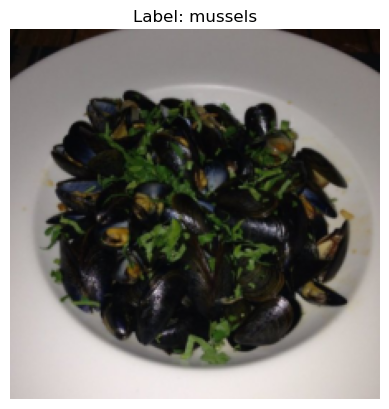

In [16]:
img, label = dataset_test[rand_idx]
img_np = imagenet_denormalize(img.permute(1,2,0).numpy())
plt.imshow(img_np)
plt.title(f"Label: {dataset_test.classes[label]}")
plt.axis('off')
plt.show()

In [17]:
cosine_similarity = nn.CosineSimilarity(dim=-1)

In [18]:
pos_embed = model._orig_mod.embedding[0,1:,:].cpu().detach()

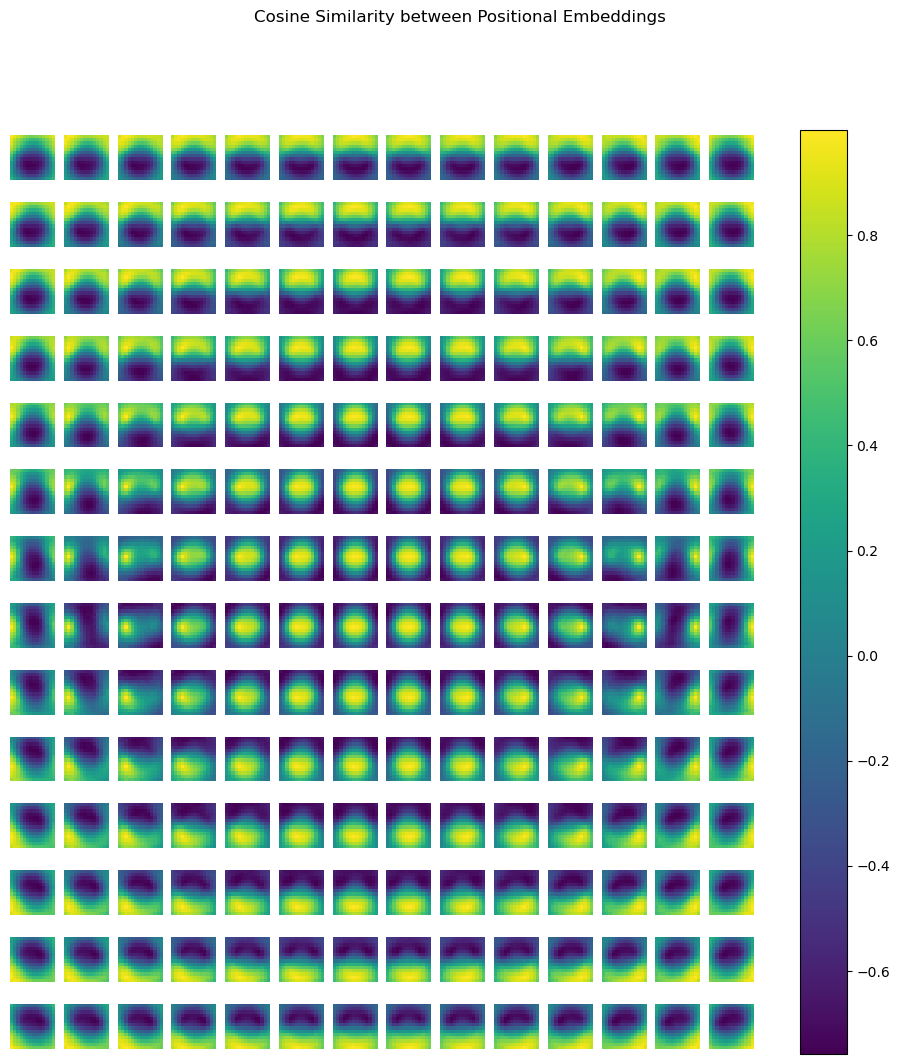

In [19]:
fig, axes = plt.subplots(nrows=14, ncols=14, figsize=(12,12))
fig.suptitle("Cosine Similarity between Positional Embeddings", fontsize=12)
for i,ax in enumerate(axes.flatten()):
    sim = cosine_similarity(pos_embed[i], pos_embed).reshape(14,14)
    im = ax.imshow(sim.numpy())
    ax.axis('off')
fig.colorbar(im, ax=axes.ravel().tolist())
plt.show()

In the training we have used flash attention for faster speed. For demonstration we need the attention scores.

In [20]:
activation = {}
def get_activation(name):
    def hook(model, input, output):
        activation[name] = input
    return hook

In [21]:
#getting q,k,v input to the encoder block
encoder_block_no =10
hook = model._orig_mod.transformer.encoder[encoder_block_no].attention.register_forward_hook(get_activation('inputs'))

In [22]:
img, label = dataset_test[rand_idx]
img = img.unsqueeze(0).to(train_config.device)
model.eval()
with torch.no_grad():
    output = model(img)
    #q,k,v input to the encoder block
    q,k,v = activation['inputs'][0], activation['inputs'][1], activation['inputs'][2]
    w_q = model._orig_mod.transformer.encoder[encoder_block_no].attention.w_q
    w_k = model._orig_mod.transformer.encoder[encoder_block_no].attention.w_k
    w_v = model._orig_mod.transformer.encoder[encoder_block_no].attention.w_v

    h = model._orig_mod.transformer.encoder[encoder_block_no].attention.h
    d_k = model._orig_mod.transformer.encoder[encoder_block_no].attention.d_k

    query = w_q(q)
    key = w_k(k)
    value = w_v(v)

    # # batch, h, seq, d_k
    query = query.view(query.shape[0], query.shape[1], h, d_k).transpose(1,2)
    key = key.view(key.shape[0], key.shape[1], h, d_k).transpose(1,2)
    value = value.view(value.shape[0], value.shape[1], h, d_k).transpose(1,2)

    ##attention scores calculation
    _, scores = MultiHeadAttention.attention(query, key, value, mask=None, dropout=None)
    scores = scores.detach().cpu().numpy()


In [23]:
scores.shape

(1, 8, 197, 197)

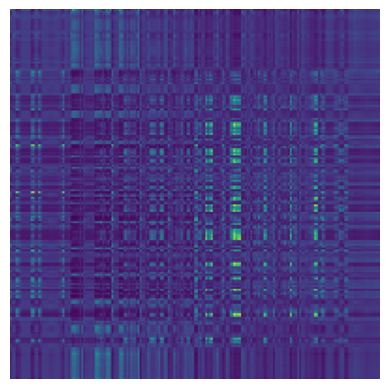

In [24]:
#attention matrix for 8th head
plt.imshow(scores[0,7])
plt.axis('off')
plt.show()

In [25]:
head = np.random.randint(0,8)

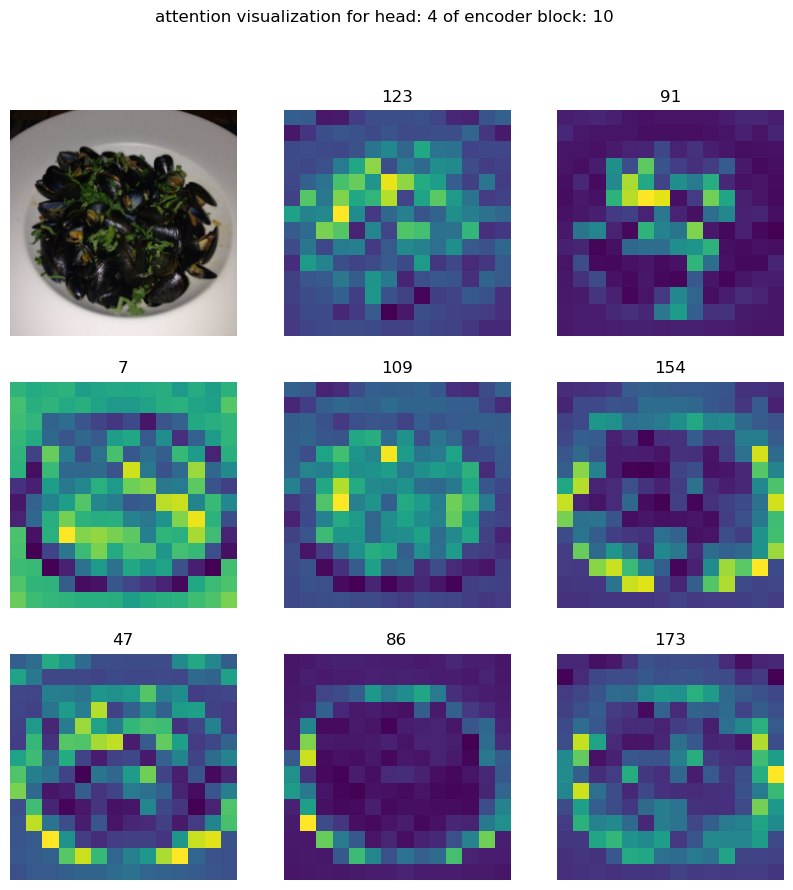

In [26]:
plt.figure(figsize=(10,10))
title = 'attention visualization for head: {} of encoder block: {}'.format(head, encoder_block_no)
# fig.suptitle(title)
plt.subplot(3,3,1)
plt.imshow(img_np)
plt.axis('off')

#random row
random_idx = np.random.randint(1,197,8)

for i,idx in enumerate(random_idx,2):
    plt.subplot(3,3,i)
    at = scores[0,head,idx,1:].reshape(14,14)
    plt.imshow(at)
    plt.axis('off')
    plt.title(str(idx))
plt.suptitle(title)
plt.show()

In [27]:
hook.remove()